# Week 1 Day 5 — MLP Classifier: Full Training Loop
**Jul 5, 2026**

Day 4 was regression, single layer, gradients by hand. Today: classification, a hidden layer, and the *real* training-loop machinery — `nn.Module`, `torch.optim`, mini-batching with `DataLoader`, and a proper train/eval split. Autograd handles the gradients now; the new work is architecture and the training-loop plumbing.

Like Day 4, this is a scaffold: every function/class below is a stub with hints, not a solution. Fill in each `# TODO`.

## Part 1: Dataset — XOR pattern

Given, not an exercise. Four clusters, labeled so the class depends on whether `x` and `y` have the *same* sign or *different* signs — the classic XOR problem. This dataset is chosen deliberately: a single `Linear` layer (logistic regression) provably cannot separate it, no matter how it's trained. That's the whole reason today's model needs a hidden layer.

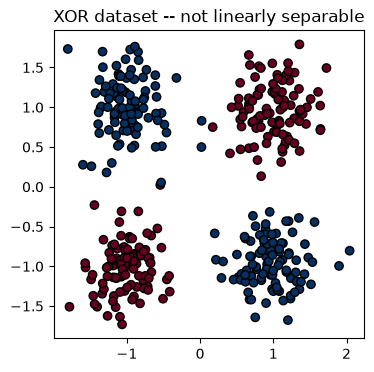

torch.Size([400, 2]) torch.Size([400])


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
n_per_cluster = 100

# (center_x, center_y, label) -- label=1 when the two signs differ (XOR)
centers = [(-1.0, -1.0, 0.0), (1.0, 1.0, 0.0), (-1.0, 1.0, 1.0), (1.0, -1.0, 1.0)]

X_parts, y_parts = [], []
for cx, cy, label in centers:
    pts = torch.randn(n_per_cluster, 2) * 0.3 + torch.tensor([cx, cy])
    X_parts.append(pts)
    y_parts.append(torch.full((n_per_cluster,), label))

X = torch.cat(X_parts)
y = torch.cat(y_parts)

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k")
plt.title("XOR dataset -- not linearly separable")
plt.show()

print(X.shape, y.shape)

## Part 2: The model — an MLP

TODO: build `MLPClassifier` as an `nn.Module` with **one hidden layer**.

Things to think about, not answers:
- You need `nn.Linear(2, hidden_dim)` then a nonlinearity then `nn.Linear(hidden_dim, 1)`. What breaks if you stack two `nn.Linear` layers with *no* nonlinearity in between? (Think back to what a composition of two linear functions actually is.)
- Output a single raw value (a *logit*), not a probability — don't apply `sigmoid` inside `forward`. That choice will matter for Part 3.
- Pick `hidden_dim` yourself — something small (a handful of units) is enough for this dataset.

In [4]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        layers = [
            nn.Linear(in_features=input_dim, out_features=hidden_dim),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim, out_features=1),
        ]
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        # TODO: pass x through the layers you defined
        return self.layers(x)

# self-check: shape only
model = MLPClassifier(input_dim=2, hidden_dim=8)
out = model(X[:5])
assert out.shape == (5, 1), f"expected shape (5, 1), got {tuple(out.shape)}"
print("shape OK")

shape OK


## Part 3: Loss and optimizer

TODO: pick a loss function and an optimizer.

- Your model outputs raw logits (Part 2), not probabilities. There's an `nn` loss class specifically meant to take logits directly for binary classification, rather than making you call `sigmoid` yourself and feed that into a plain BCE loss — look for it; it's also more numerically stable than doing the two steps separately. Its target tensor needs the same shape as your model's output, so check `y`'s shape against that.
- For the optimizer, `torch.optim.Adam` on `model.parameters()` is a reasonable default here — pick a learning rate (start around `1e-2` and adjust if training looks unstable or too slow once you get to Part 5).

In [5]:
# TODO: criterion = ...
loss_fn = nn.BCEWithLogitsLoss()


# TODO: optimizer = ...
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Part 4: Mini-batching with `DataLoader`

So far every notebook has fed the *entire* dataset through the model each step. Real training loops iterate over shuffled mini-batches instead. TODO: wrap `X` and `y` in a `TensorDataset`, then a `DataLoader` (pick a `batch_size`, e.g. 32, and `shuffle=True`).

In [6]:
from torch.utils.data import TensorDataset, DataLoader

# TODO: dataset = TensorDataset(...)
dataset = TensorDataset(X, y)
# TODO: loader = DataLoader(...)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# self-check: pull one batch and inspect shapes
xb, yb = next(iter(loader))
print(xb.shape, yb.shape)

torch.Size([32, 2]) torch.Size([32])


## Part 5: The training loop

TODO: for each epoch, iterate over `loader` and for every batch: zero the gradients, forward pass, compute loss, backward pass, optimizer step. Track the average loss per epoch.

Watch out for the shape your loss function expects for its target — you already checked this in Part 3; if training errors out or the loss looks wrong, that mismatch is the first thing to check.

epoch  20 | loss 0.3036
epoch  40 | loss 0.2540
epoch  60 | loss 0.2174
epoch  80 | loss 0.1891
epoch 100 | loss 0.1669


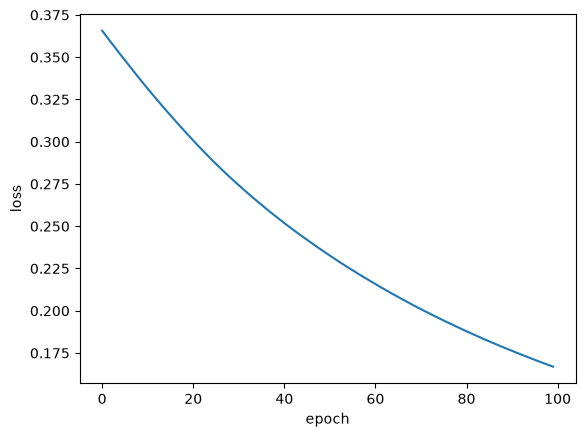

In [11]:
n_epochs = 100
losses = []

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for xb, yb in loader:
        # TODO: zero_grad, forward, loss, backward, step
        optimizer.zero_grad()
        outputs = model(xb)
        
        # TODO: accumulate epoch_loss (e.g. += loss.item() * xb.shape[0])
        loss = loss_fn(outputs.squeeze(), yb)
        
       
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * xb.shape[0]
       

    epoch_loss /= len(dataset)
    losses.append(epoch_loss)

    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch+1:3d} | loss {epoch_loss:.4f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

## Part 6: Evaluation

TODO: write `evaluate(model, X, y)` returning accuracy.

- Two things every eval loop needs that a training loop doesn't: `model.eval()` (matters more once you add dropout/batchnorm, but it's the right habit now) and `torch.no_grad()` (no gradient tracking needed, saves memory/compute — this is Day 3 Part 4).
- Your model outputs raw logits. To get a hard 0/1 prediction from a logit without first computing `sigmoid`, what's the sign-based shortcut? (Think about what `sigmoid(x) > 0.5` corresponds to in terms of `x` itself.)

In [12]:
def evaluate(model, X, y):
    accuracy = 0.0
    with torch.no_grad():
        outputs = model(X)
        predictions = torch.sigmoid(outputs).squeeze() >= 0.5
        accuracy = (predictions == y).float().mean().item()
    # TODO: return accuracy as a float between 0 and 1
    return accuracy


acc = evaluate(model, X, y)
print(f"accuracy: {acc:.3f}")

accuracy: 0.983


## Part 7 (bonus): Visualize the decision boundary

Given, not an exercise — this just shades the 2D plane by what your trained model predicts at every point, so you can *see* whether it learned the XOR pattern's nonlinear (X-shaped) boundary.

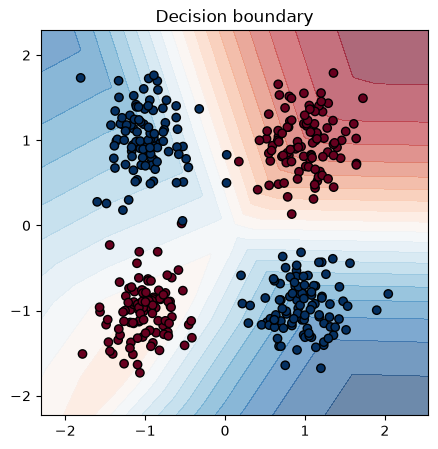

In [10]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200), torch.linspace(y_min, y_max, 200), indexing="xy"
    )
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

    model.eval()
    with torch.no_grad():
        logits = model(grid).squeeze(-1)
    probs = torch.sigmoid(logits).reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx.numpy(), yy.numpy(), probs.numpy(), levels=20, cmap="RdBu", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k")
    plt.title("Decision boundary")
    plt.show()

plot_decision_boundary(model, X, y)

## Try yourself

1. Set `hidden_dim` in a fresh model down to something that removes the nonlinearity entirely (or skip the activation function) and retrain. Confirm accuracy collapses toward 50% — direct proof that a linear model can't solve XOR, no matter how well-trained.
2. Split `X`/`y` into train and validation sets *before* Part 4 (e.g. `torch.utils.data.random_split` or manual index slicing), train only on the train split, and call `evaluate` on both. Do they diverge?
3. Swap `Adam` for plain `SGD` at the same learning rate — how much does convergence speed change?
4. Replace the XOR dataset with a binary "default vs. no-default" synthetic dataset built from several continuous features (leverage, volatility, etc.) instead of 2D points — same model and training loop, different data.